In [1]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import numpy as np
from numpy import *
import seaborn as sns

def max2(x):
    if len(x)==1: return x[0]
    x2 = x.copy()#复制一份，不破坏原来的列表
    x2.sort()#从小到大排序
    m1 = x2[-1]#最后一个元素最大
    m2 = x2[-2]#倒数第二个元素第二大
    return (m2+m1)/2  #m1是第二大的值,m2是最大值
def onetwo(l):
    # 找到最小值
    min_value = min(l)
    # 将列表中的最小值替换为1，其余替换为2
    result_list = [1 if x == min_value else 2 for x in l if x is not None]
    return(result_list)

In [2]:
file = glob(r'trace/*hmm2states.csv')
trace_df = pd.DataFrame(columns=['path_file','gene','firstoff','length'])


In [3]:
for i in file:
    gene = 'FOS'
    trace =pd.read_csv(i)
    if 'empty' not in i:
        hmm_seq = "".join([str(string) for string in list(trace['HMMStates'])])
        sequence = hmm_seq
        #off state
        if hmm_seq[0] == '1':
            firstoff = 0
            matches = re.findall(r'1+', hmm_seq)
            lengths = [len(match) for match in matches]
            if len(lengths)==0 : firstoff = 0
            else: firstoff = lengths[0]
            item = [i,gene,firstoff,len(trace)]
            trace_df.loc[len(trace_df)]=item
        elif hmm_seq[0] == '2':
            firstoff = 0
            matches = re.findall(r'2+', hmm_seq)
            lengths = [len(match) for match in matches]
            if len(lengths)==0 : firstoff = 0
            else: firstoff = 0 - lengths[0]
            item = [i,gene,firstoff,len(trace)]
            trace_df.loc[len(trace_df)]=item

    if 'empty' in i:
        firstoff = len(trace)
        item = [path,i,gene,firstoff,len(trace)]
        trace_df.loc[len(trace_df)]=item


In [4]:
trace

,X,particle_index,POSITION_T,Reg_X,Reg_Y,Org_X,Org_Y,local_maxima,Fit_X,Fit_Y,Fit_amp,Fit_offset,photon_number,TP_Flag,HMMStates
0,0,0,0,83.2500,50.687500,83.250000,50.687500,83,87.110011,51.889428,9.425778,17.474969,105.896666,NaN,1
1,1,0,1,83.2500,50.687500,83.312994,50.680127,86,84.455169,48.804143,22.882209,5.383014,147.253109,NaN,1
2,2,0,2,83.2500,50.687500,83.376000,50.672853,88,81.675615,52.697793,20.634962,12.645296,117.878320,NaN,1
3,3,0,3,83.2500,50.687500,83.250000,50.687500,77,85.605307,49.496567,12.385651,9.112746,136.164357,NaN,1
4,4,0,4,83.2500,50.687500,83.187018,50.694971,73,83.176909,53.558553,2.740583,11.009069,117.000092,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,62,0,62,83.8750,48.666667,87.922511,48.466240,125,87.712950,48.969233,29.568239,11.622411,187.910430,NaN,2
63,63,0,63,81.1875,48.583333,85.322132,48.123284,120,85.818958,49.422411,36.275468,5.417245,263.094586,NaN,2
64,64,0,64,78.5000,48.500000,77.837123,48.653619,127,77.873643,48.771417,55.468268,6.567748,348.018148,1.0,2
65,65,0,65,78.5000,48.500000,77.572659,48.717964,103,78.937779,48.993012,11.013641,14.222737,255.173296,NaN,2


In [5]:
import seaborn as sns

for i in list(set(trace_df['gene'])):
    df_hand = trace_df[trace_df['gene']==i]
    df_hand = df_hand.sort_values(by=['firstoff'],ascending=[True])
    #df_hand = df_hand[df_hand['length']>=200]
    df_plot = pd.DataFrame()
    for j in range(len(df_hand)):
        if 'hmm' in df_hand['path_file'].values[j]:
            df_single=pd.read_csv(df_hand['path_file'].values[j])
            df_plot = pd.concat([df_plot,df_single['photon_number']],axis=1)
        else:
            df_single=pd.read_csv(df_hand['path_file'].values[j])
            df_plot = pd.concat([df_plot,df_single[2]],axis=1)
        if df_plot.shape[1]<2:continue
        df_plot.T.to_csv(r"result\plot\heatmap-{}-matrix.csv".format(i),index=None)
df_hand.to_csv(r"result\plot\heatmap-tracefile.csv".format(i),index=None)

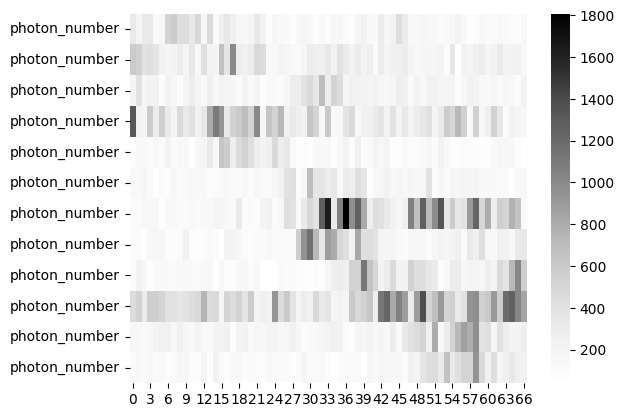

In [6]:
sns.heatmap(df_plot.T, cmap ='Greys')
plt.savefig('result/plot/heatmap(raw).png',dpi=300)

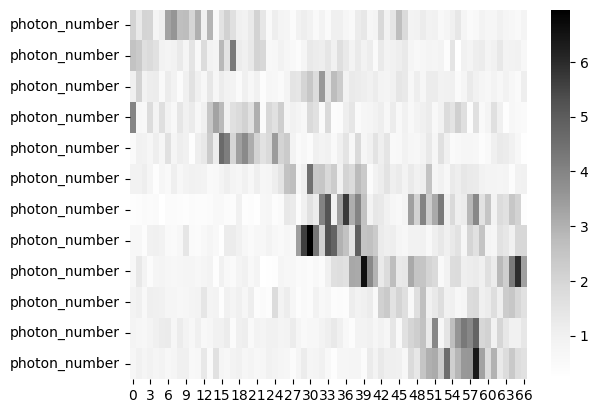

In [7]:
df_plot = df_plot/df_plot.median()
sns.heatmap(df_plot.T, cmap ='Greys')
plt.savefig('result/plot/heatmap(normedByMedian).png',dpi=300)